## Alunos:
- Igor Correa Trifilio Campos - 202365092AB
- Davi Luís de Faria Rocha - 202365519B


In [ ]:
!pip install anastruct

from PIL import Image
import matplotlib.pyplot as plt
from urllib.request import urlopen
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from anastruct import SystemElements

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.2/783.2 kB 12.0 MB/s eta 0:00:00


# Questão 1

# Estrutura escolhida: Portão da Índia
## [Link para a modelagem 3D no google arts and culture](https://artsandculture.google.com/asset/3d-model-of-gateway-of-india-india-cyark/JAE__LXR9I6lkA?hl=en) feita por [CyArk](https://www.cyark.org/whoweare/)


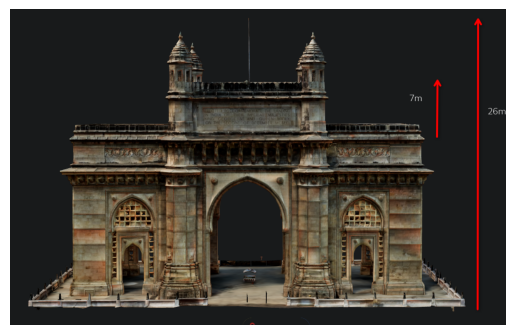

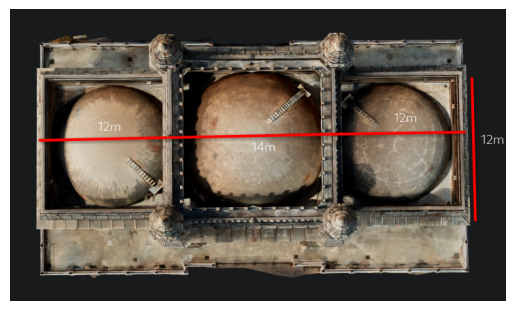

In [ ]:
def carregador_imagem(nome_arquivo):
    url = 'https://raw.githubusercontent.com/Rogire/Trabalho-MAC019/main/images/' + nome_arquivo
    img = Image.open(urlopen(url))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
carregador_imagem("altura.png")
carregador_imagem("largura.png")

## Características
### Informações conhecidas
- 26 Metros de altura
- O domo principal da estrutura possui 14 metros de diâmetro
- A estrutura é feita de basalto e concreto armado
- A estrutura simétrica logo os lados opostos vão ter módulos iguais

### Aproximações
Por falta de informações públicas divulgadas sobre a estrutura, algumas aproximações foram feitas
- O valor dos demais domos foi aproximado como 11 metros
    - 3 domos: 11 + 14 + 11 =36 Metros de largura
    - 12 metros de espessura
- A laje que compõe o carregamento distribuído sobre a viga tem 4 paredes, 3 torres e uma cúpula oca
  -  O carregamento distribuído considerado foi o de uma das paredes e multiplicado por um fator de segurança, considerando a **densidade cúbica** da parede
  - A altura das paredes foi estimada como o raio de seu domo, sendo 6 metros para as paredes das pontas e 7 metros para a do meio
  - A largura das paredes da ponta foi estimada pelo valor do diâmetro dos domos: 12 metros
  - Por falta de informações, a espessura das paredes foi estimada como 1 metros
- A densidade do basalto com centro armado foi aproximada como  $ρ ≈ 2500 kg/m³ (≈ 25 kN/m³)$ tendo em vista os valores usuais em construções.
#### Estimativa do módulo de Elasticidade e momento de Inércia
- Os valores regulares do E para concreto armado variam entre 25 e 30 GPa, então o valor de 27.5 GPa foi adotado para considerar uma margem uniforme
- Considerando a estrutura como vigas retangulares o momento de inércia para todas as barras do sistema segue a mesma fórmula tabelada $I = \frac{bh³}{12}$

#### Estimativa do carregamento distribuído

- O carregamento distribuído das lajes sobre cada barra foi aproximado pelo peso das paredes multiplicado por um fator de correção para considerar os demais elementos presentes
- Paredes das bordas:
  - $V_B = a*b*h = 11*6*1 = 66 m³$
- Parede central:
  - $V_C = a*b*h = 14*7*1 = 98m³$

- O fator de correção foi colocado como 30%: $\delta = 1.3$

- Massa valor central:
  - $M_c = V_C * \delta * \rho= 98 * 1.3 *2500 = 318500 Kg \approx 3.185*10^5 Kg$

- Massa valor bordas:
  - $M_b = V_B * \delta * \rho= 66 * 1.3 *2500 = 214500 Kg ≈ 2.145*10^5 Kg$

- Os carregamentos vão ser dado pelo peso dessas estruturas
  - Q = $M_c*g \approx 3.185*10^5 * 9.81 = 31,24485 *10^5 \approx 3,1 * 10^6$
  - q = $M_b*g \approx 2.145*10^5 * 9.81 = 20,9934 *10^5  \approx 2,1 * 10^6$

### Simplificação Adotada: Simplificação de barras inextensíveis
  - Considerando as barras da viga principal como inextensíveis, os nós do sistema passam a ter apenas um grau de liberdade e dessa forma tem **4 Deslocabilidades e 5 casos**

## Dois métodos de resolução:
### Analítico
- A resolução foi feita na mão até montar a matriz de deslocabilidade K para as deslocabilidades dos nós 1,2,3 e 4, depois disso pode resolver com Python, os diagramas podem ser feito em Python ou na mão

## Numérico
- Com a simplificação -> 4 Deslocabilidades
- Sem a simplificação



# Montagem da matriz analítica K


A montagem da matriz leva em conta o deslocamento da matriz estrutura em cada caso, e a força de resistência $k_{ij}$ que surge em cada barra sempre considerando as contribuições de cada uma das barras da viga e pilar conectada aos nós.

In [ ]:
#imagem resolução

Dessa forma, o sistema final fica estabelecido como:

$$
\begin{equation}
\begin{bmatrix}
\beta_{10} \\
\beta_{20} \\
\beta_{30} \\
\beta_{40}
\end{bmatrix}
+
\begin{bmatrix}
k_{11} & k_{12} & 0 & 0 \\
k_{21} & k_{22} & k_{23} & 0 \\
0 & k_{32} & k_{33} & k_{34} \\
0 & 0 & k_{23} & k_{34}
\end{bmatrix}
\cdot
\begin{bmatrix}
D_1 \\
D_2 \\ 
D_3 \\ 
D_4 
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ 0 \\ 0
\end{bmatrix}
\end{equation}
$$

In [ ]:
def I(b,h):
    return (b*h**3)/12


E = 27.5 * 10**9
l = 11
L = 14
h =19

I_barra = I(1,L)

k11 = EI * (4/h + 6/l**2)
k21 = 2*EI/l
k31 = 0
k41 = 0

k12 = 2*EI/l
k22 = EI * (4/l + 6/L**2 + 6/h**2)
k32 = 2*EI/l
k42 = 0

k13 = 0
k23 = 2*EI/l
k33 = EI * (4/l + 6/L**2 + 6/h**2)
k43 = 2*EI/l

k14 = 0
k24 = 0
k34 = 2*EI/l
k44 = EI * (4/h + 6/l**2)


## Solução dos casos
#### Caso 0:
  No primeiro caso, supomos deslocamento em nenhum dos nós do sistema, dessa forma o valor de cada k se torna o valor do próprio momento de engastamento perfeito, que considera as infliências de todas as barras conectadas aquele nó. Dessa forma os valores são dados diretamente pela tabela:

In [ ]:
carregador_imagem('tabela_momento_perfeito.png')

Dessa forma a os valores encontrados para o caso 0 são:
$ \beta _{10}= 2.11 \cdot 10^7$
$ \beta _{20}= 2.95 \cdot 10^7$
$ \beta _{30}= -2.95 \cdot 10^7$
$ \beta _{40}= -2.11 \cdot 10^7$


In [ ]:
carregador_imagem('tabela_momento_perfeito.png')

### Solução feita sem a simplificação de barras inextensíveis:
- 12 deslocabilidades

# Modelagem no Anastruct

Estrutura


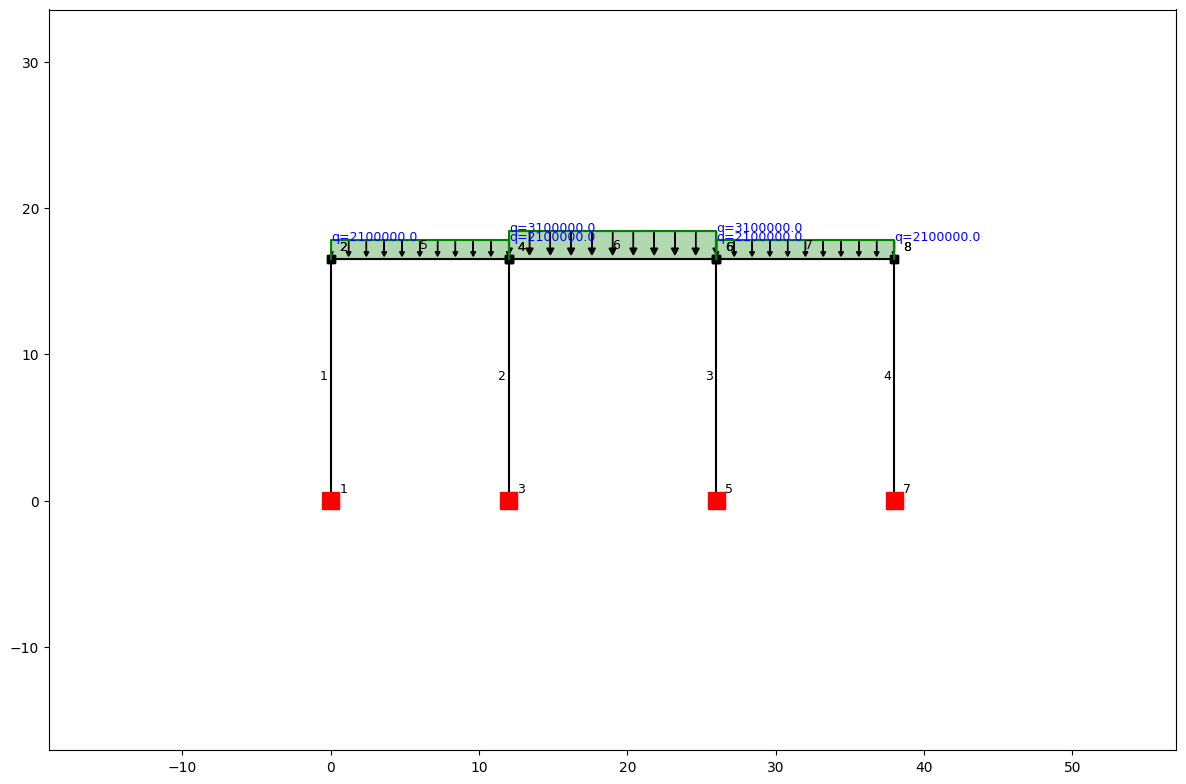

Reações de apoio


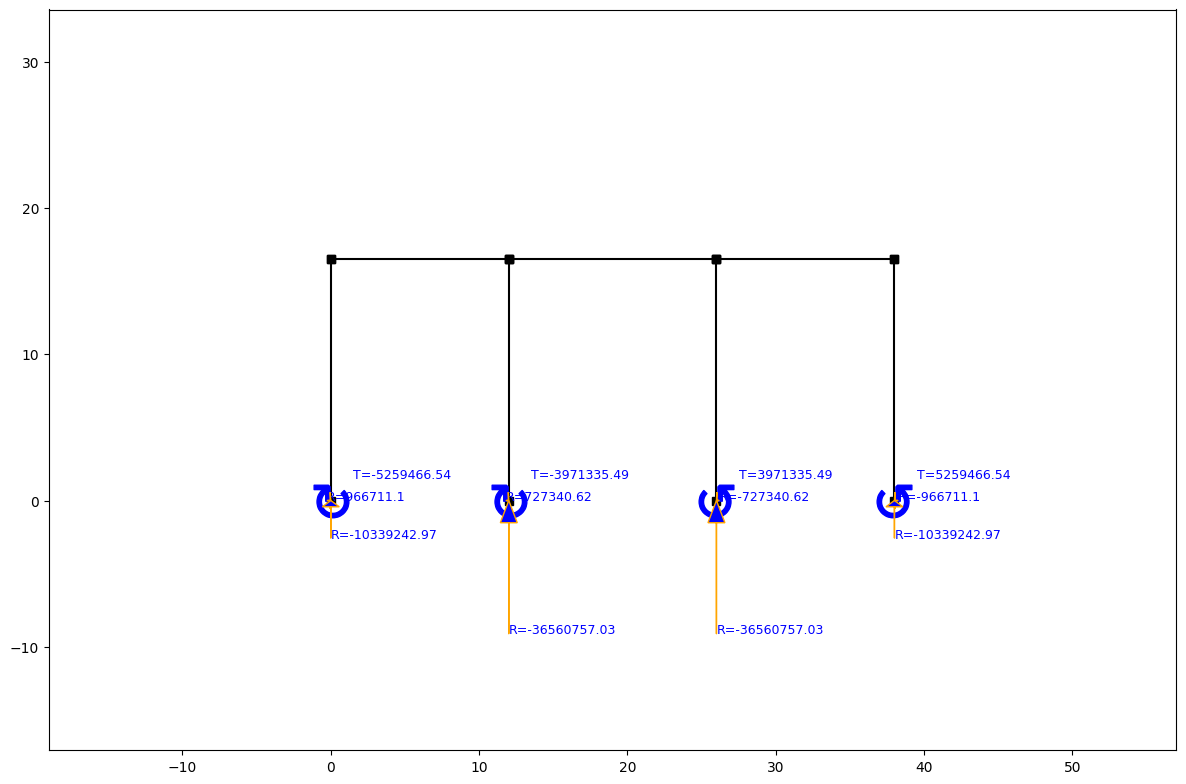

Diagrama de Esforço Cortante


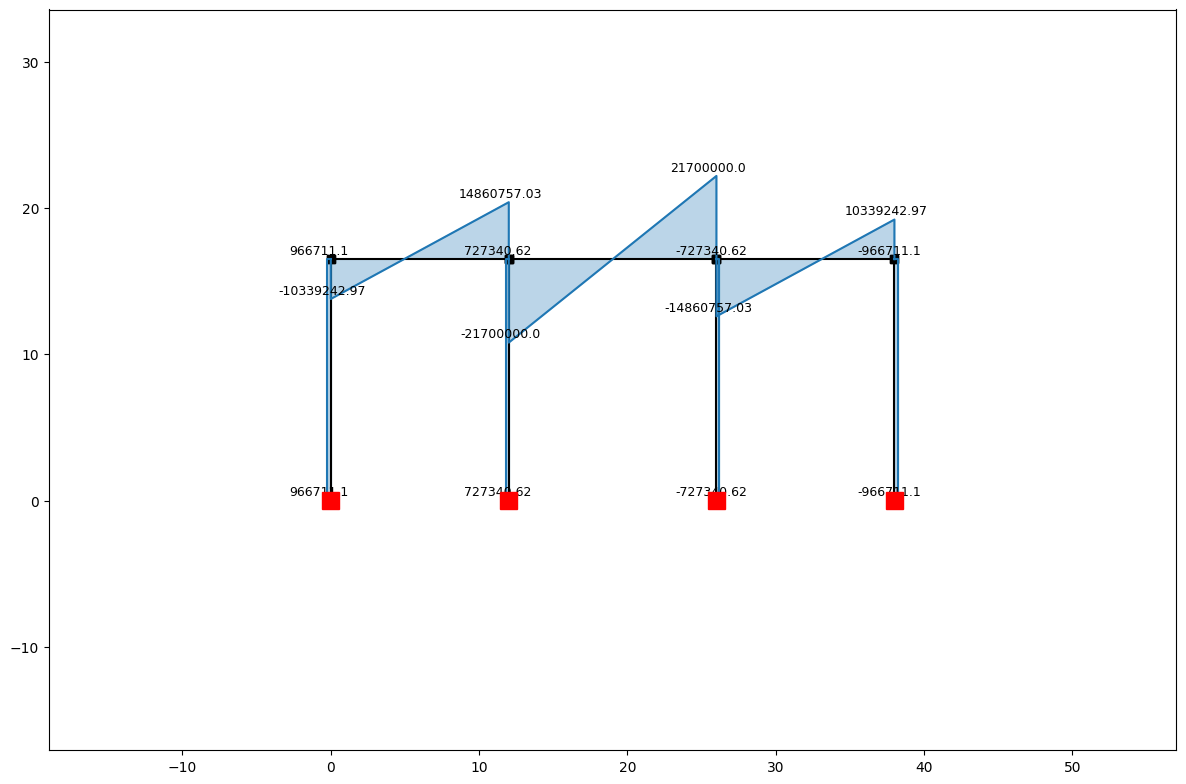

Diagrama de Momento Fletor


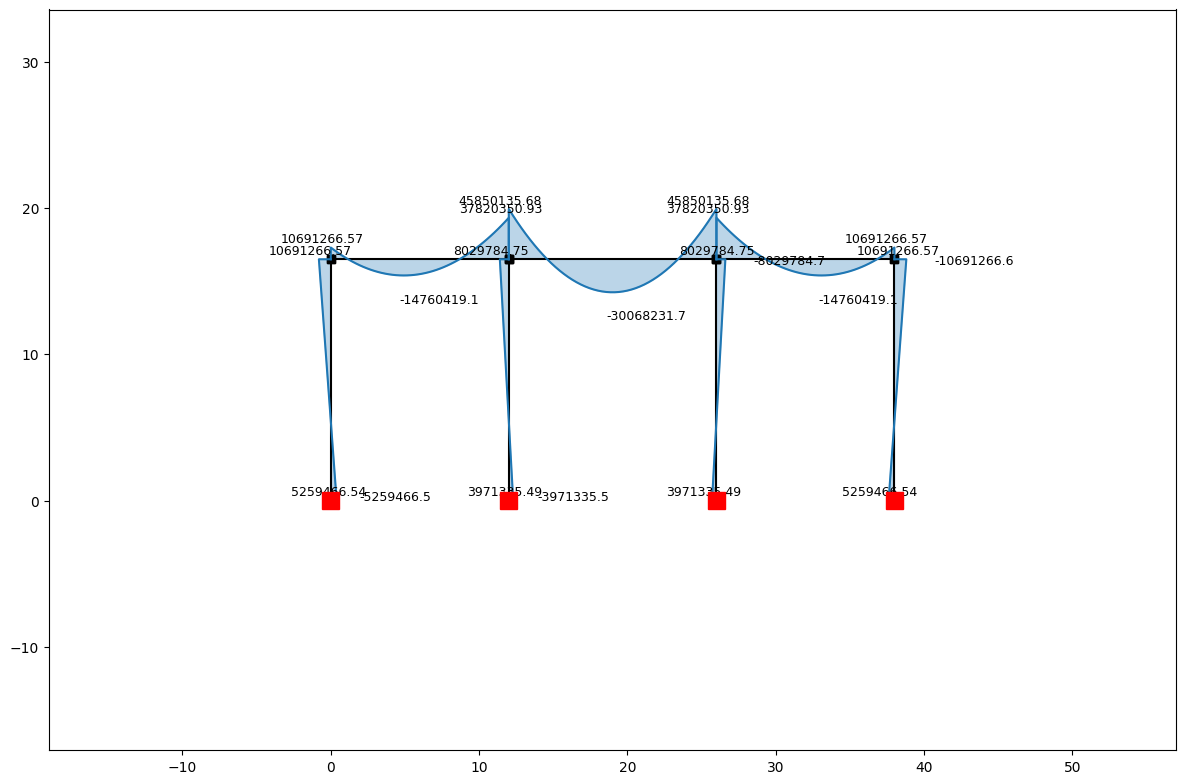

Linha elástica: 


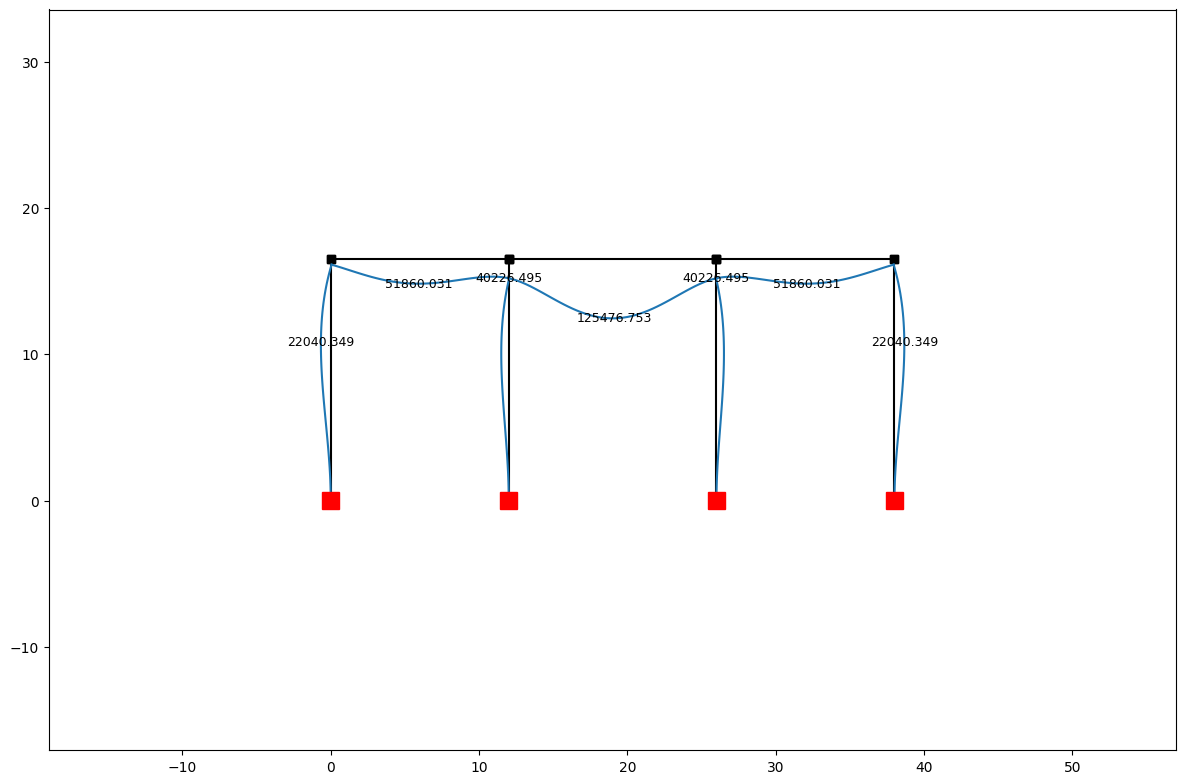

In [ ]:
SS = SystemElements()

def solve_system(ss):
    print("Estrutura")
    ss.show_structure()
    ss.solve()
    print("Reações de apoio")
    ss.show_reaction_force()
    print("Diagrama de Esforço Cortante")
    ss.show_shear_force()
    print("Diagrama de Momento Fletor")
    ss.show_bending_moment()
    print("Linha elástica: ")
    ss.show_displacement()

elements = [
    [[0.0,0.0],[0.0,16.5]],
    [[12.0,0.0],[12.0,16.5]],
    [[26.0,0.0],[26.0,16.5]],
    [[38.0,0.0],[38.0,16.5]],

    [[0.0,16.5],[12.0,16.5]],
    [[12.0,16.5],[26.0,16.5]],
    [[26.0,16.5],[38.0,16.5]],
]
# Valores estimados de carregamento demonstrados acima
Q = 3.1e6
q = 2.1e6

for i in elements:
    SS.add_element(i)

SS.q_load(element_id=5,q=-q, direction='element')
SS.q_load(element_id=6,q=-Q, direction='element')
SS.q_load(element_id=7,q=-q, direction='element')

SS.add_support_fixed(node_id=1)
SS.add_support_fixed(node_id=3)
SS.add_support_fixed(node_id=5)
SS.add_support_fixed(node_id=7)


solve_system(SS)